# Test the DuckDB


## Create environment

```
# Create the environment
conda env create -f workflow/envs/duckdb_analysis.yaml

# Activate it
conda activate duckdb_analysis

# Register it as a Jupyter kernel
python -m ipykernel install --user --name duckdb_analysis --display-name "DuckDB Analysis"
```



In [31]:
# Cell 1: Setup
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Database path (adjust if needed)
DB_PATH = '../../data/databases/phage_database_optimized.duckdb'


In [32]:
# Cell 2: Connect to Database
conn = duckdb.connect(DB_PATH, read_only=True)

print("✅ Connected to database!")
print(f"📍 Database location: {DB_PATH}")


✅ Connected to database!
📍 Database location: ../../data/databases/phage_database_optimized.duckdb


In [33]:
# Cell 3: Database Overview
print("🗄️ Database Tables:")
tables = conn.execute("SHOW TABLES").df()
print(tables)

print("\n📊 Database Views:")
views = conn.execute("SELECT name FROM sqlite_master WHERE type='view'").df()
print(views)

🗄️ Database Tables:
                         name
0             dim_anti_crispr
1                dim_proteins
2             dim_terminators
3  dim_transmembrane_proteins
4              dim_trna_tmrna
5        dim_virulent_factors
6                 fact_phages
7      phage_complete_profile
8     phage_size_distribution
9               phage_summary

📊 Database Views:
                      name
0   phage_complete_profile
1  phage_size_distribution
2            phage_summary


In [34]:
# Cell 4: Quick Statistics
stats = conn.execute("""
    SELECT 
        'Phages' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM fact_phages
    UNION ALL
    SELECT 
        'Proteins' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM dim_proteins
    UNION ALL
    SELECT 
        'Terminators' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM dim_terminators
    UNION ALL
    SELECT 
        'Anti-CRISPR' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM dim_anti_crispr
    UNION ALL
    SELECT 
        'Virulent Factors' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM dim_virulent_factors
    UNION ALL
    SELECT 
        'Transmembrane' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM dim_transmembrane_proteins
    UNION ALL
    SELECT 
        'tRNA/tmRNA' as entity,
        COUNT(*) as total,
        COUNT(DISTINCT Source_DB) as sources
    FROM dim_trna_tmrna
""").df()

print("\n📈 Database Statistics:")
print(stats.to_string(index=False))


📈 Database Statistics:
          entity    total  sources
          Phages   873718       14
        Proteins 20276531        9
     Terminators  4229116       10
     Anti-CRISPR   299832       13
Virulent Factors    23764       10
   Transmembrane  2820232       13
      tRNA/tmRNA  1298181       14


In [35]:
# Cell 5: Source Distribution
source_stats = conn.execute("""
    SELECT 
        Source_DB,
        COUNT(*) as phage_count,
        AVG(Length) as avg_length,
        AVG(GC_content) as avg_gc,
        MIN(Length) as min_length,
        MAX(Length) as max_length
    FROM fact_phages 
    WHERE Length IS NOT NULL
    GROUP BY Source_DB
    ORDER BY phage_count DESC
""").df()

print("\n🌍 Phage Distribution by Source:")
print(source_stats)

# Visualize
fig = px.bar(source_stats, 
             x='Source_DB', 
             y='phage_count',
             title='Phage Count by Source Database',
             labels={'phage_count': 'Number of Phages', 'Source_DB': 'Source Database'},
             color='avg_length',
             color_continuous_scale='Viridis')
fig.show()




🌍 Phage Distribution by Source:
   Source_DB  phage_count    avg_length     avg_gc  min_length  max_length
0       GOV2       195699  21558.270850  39.448446       10001      505180
1        MGV       189680  46410.915806  45.005857        1244      553716
2      IMGVR       177361  49134.806615  46.611572        2175      553716
3        GPD       142809  37586.308958  43.998845       10000      419037
4     TemPhD        66823  39149.977283  47.266332        9303       99934
5       CHVD        44935  32145.646133  44.637906         970      500746
6        GVD        31402  18279.739061  43.706776        1531      392017
7       IGVD        10021  25019.544856  44.035016        1022      266223
8     RefSeq         4637  70575.313349  49.400531         203      497513
9        STV         4065  25071.745141  58.844832       10006      259025
10  PhagesDB         3754  61343.346564  63.377244       14270      194724
11   Genbank         2086  72231.801055  47.517686        2322     

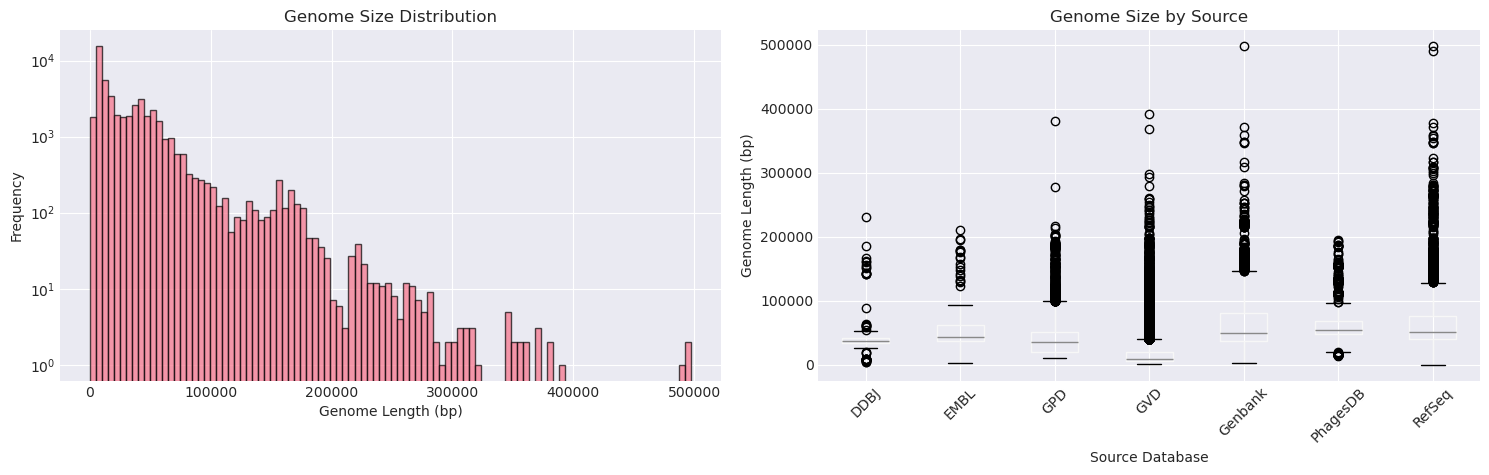

In [36]:
# Cell 6: Genome Size Distribution
genome_sizes = conn.execute("""
    SELECT Length, GC_content, Source_DB
    FROM fact_phages 
    WHERE Length IS NOT NULL AND Length > 0
    LIMIT 50000
""").df()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(genome_sizes['Length'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Genome Length (bp)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Genome Size Distribution')
axes[0].set_yscale('log')

# Box plot by source
genome_sizes.boxplot(column='Length', by='Source_DB', ax=axes[1], rot=45)
axes[1].set_xlabel('Source Database')
axes[1].set_ylabel('Genome Length (bp)')
axes[1].set_title('Genome Size by Source')
plt.suptitle('')
plt.tight_layout()
plt.show()



In [37]:
# Cell 7: GC Content Analysis
gc_data = conn.execute("""
    SELECT GC_content, Length, Source_DB
    FROM fact_phages 
    WHERE GC_content IS NOT NULL AND Length IS NOT NULL
    LIMIT 50000
""").df()

fig = px.scatter(gc_data, 
                 x='Length', 
                 y='GC_content',
                 color='Source_DB',
                 title='Genome Length vs GC Content',
                 labels={'Length': 'Genome Length (bp)', 'GC_content': 'GC Content (%)'},
                 opacity=0.5,
                 hover_data=['Source_DB'])
fig.show()



In [38]:
# Cell 8: Protein Analysis
protein_stats = conn.execute("""
    SELECT 
        Source_DB,
        COUNT(*) as protein_count,
        COUNT(DISTINCT Phage_ID) as phage_count,
        CAST(COUNT(*) AS FLOAT) / COUNT(DISTINCT Phage_ID) as proteins_per_phage,
        AVG(Molecular_weight) as avg_mw,
        AVG(Isoelectric_point) as avg_pi
    FROM dim_proteins
    WHERE Molecular_weight IS NOT NULL
    GROUP BY Source_DB
    ORDER BY protein_count DESC
""").df()

print("\n🧬 Protein Statistics by Source:")
print(protein_stats)




🧬 Protein Statistics by Source:
  Source_DB  protein_count  phage_count  proteins_per_phage       avg_mw  \
0       MGV        8988926       189680           47.389950  4138.146022   
1       GPD        6392036       142800           44.762157  4191.276843   
2    TemPhD        3172653        66823           47.478458  4054.394770   
3       GVD         646008        31263           20.663660  4164.106772   
4    RefSeq         481765         4635          103.940666  4123.384336   
5  PhagesDB         342205         3754           91.157433  4052.119767   
6   Genbank         217816         2064          105.531006  4143.394888   
7      DDBJ          17391          290           59.968964  4130.697357   
8      EMBL          11100          147           75.510201  4096.091561   

     avg_pi  
0  6.777067  
1  6.761913  
2  7.050782  
3  6.783227  
4  6.812035  
5  6.762128  
6  6.731248  
7  7.118349  
8  6.878084  


In [39]:
# Cell 9: Protein Classification Distribution (Enhanced)
protein_class = conn.execute("""
    SELECT 
        Protein_classification,
        COUNT(*) as count,
        COUNT(DISTINCT Phage_ID) as unique_phages
    FROM dim_proteins
    WHERE Protein_classification IS NOT NULL 
        AND Protein_classification != '-'
    GROUP BY Protein_classification
    ORDER BY count DESC
    LIMIT 20
""").df()

fig = px.bar(protein_class, 
             x='Protein_classification', 
             y='count',
             title='Top 20 Protein Classifications',
             labels={'count': 'Number of Proteins', 'Protein_classification': 'Classification'},
             color='count',
             color_continuous_scale='Plotly3')

# Enhanced styling
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title="Protein Classification",
    yaxis_title="Count",
    height=600,
    showlegend=False,
    font=dict(size=12)
)

fig.show()

In [ ]:
# Cell 10: Complex Query - Phage Characterization
phage_profile = conn.execute("""
    SELECT 
        f.Phage_ID,
        f.Source_DB,
        f.Length,
        f.GC_content,
        f.Host,
        f.Lifestyle,
        COUNT(DISTINCT p.Protein_ID) as protein_count,
        COUNT(DISTINCT t.terminator_type) as terminator_types,
        COUNT(DISTINCT a.Protein_ID) as anti_crispr_count,
        COUNT(DISTINCT v.Protein_ID) as virulent_factor_count,
        COUNT(DISTINCT tm.Protein_ID) as transmembrane_count,
        COUNT(DISTINCT tr.trna_tmrna_id) as trna_count,
        AVG(p.Molecular_weight) as avg_protein_mw
    FROM fact_phages f
    LEFT JOIN dim_proteins p ON f.Phage_ID = p.Phage_ID
    LEFT JOIN dim_terminators t ON f.Phage_ID = t.Phage_ID
    LEFT JOIN dim_anti_crispr a ON f.Phage_ID = a.Phage_ID
    LEFT JOIN dim_virulent_factors v ON f.Phage_ID = v.Phage_ID
    LEFT JOIN dim_transmembrane_proteins tm ON f.Phage_ID = tm.Phage_ID
    LEFT JOIN dim_trna_tmrna tr ON f.Phage_ID = tr.Phage_ID
    WHERE f.Length > 50000
    GROUP BY f.Phage_ID, f.Source_DB, f.Length, f.GC_content, f.Host, f.Lifestyle
    ORDER BY f.Length DESC
    LIMIT 100
""").df()

print("\n🔬 Large Phage Profiles (>50kb):")
print(phage_profile.head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# Cell 11: Anti-CRISPR Analysis
acr_stats = conn.execute("""
    SELECT 
        Source_DB,
        COUNT(*) as acr_count,
        COUNT(DISTINCT Phage_ID) as unique_phages,
        COUNT(DISTINCT Source) as source_types
    FROM dim_anti_crispr
    GROUP BY Source_DB
    ORDER BY acr_count DESC
""").df()

print("\n🛡️ Anti-CRISPR Statistics by Source:")
print(acr_stats)

# Visualize
fig = px.bar(acr_stats, 
             x='Source_DB', 
             y='acr_count',
             title='Anti-CRISPR Systems by Source Database',
             labels={'acr_count': 'Number of Anti-CRISPR', 'Source_DB': 'Source Database'},
             color='unique_phages',
             color_continuous_scale='Reds')

fig.update_layout(xaxis_tickangle=-45)
fig.show()


🛡️ Anti-CRISPR Statistics by Source:
   Source_DB  acr_count  unique_phages  source_types
0     RefSeq     115583           4571             3
1    Genbank      54816           2022             3
2       GOV2      36246          35255             2
3        GPD      26249          25238             3
4        MGV      24692          23664             3
5      IMGVR      20338          19374             3
6       CHVD       7256           6982             3
7        GVD       4882           4747             2
8       DDBJ       4803            287             1
9       EMBL       2807            138             3
10      IGVD       1523           1467             2
11       STV        589            573             2
12  PhagesDB         48             48             2


In [ ]:
# Cell 14: tRNA/tmRNA Analysis
trna_stats = conn.execute("""
    SELECT 
        trna_type,
        COUNT(*) as count,
        COUNT(DISTINCT Phage_ID) as unique_phages,
        AVG(length) as avg_length
    FROM dim_trna_tmrna
    WHERE trna_type IS NOT NULL
    GROUP BY trna_type
    ORDER BY count DESC
    LIMIT 25
""").df()

print("\n🧬 Top 25 tRNA/tmRNA Types:")
print(trna_stats)

# Visualize
fig = px.bar(trna_stats, 
             x='trna_type', 
             y='count',
             title='Top 25 tRNA/tmRNA Types',
             labels={'count': 'Number of tRNA/tmRNA', 'trna_type': 'Type'},
             color='unique_phages',
             color_continuous_scale='Greens')

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)
fig.show()

# Strand distribution
strand_stats = conn.execute("""
    SELECT 
        Strand,
        COUNT(*) as count,
        COUNT(DISTINCT Phage_ID) as unique_phages
    FROM dim_trna_tmrna
    WHERE Strand IS NOT NULL
    GROUP BY Strand
    ORDER BY count DESC
""").df()

print("\n➡️ tRNA/tmRNA Strand Distribution:")
print(strand_stats)

# Source distribution
trna_source_stats = conn.execute("""
    SELECT 
        Source_DB,
        COUNT(*) as trna_count,
        COUNT(DISTINCT Phage_ID) as unique_phages,
        COUNT(DISTINCT trna_type) as unique_types
    FROM dim_trna_tmrna
    GROUP BY Source_DB
    ORDER BY trna_count DESC
""").df()

print("\n📊 tRNA/tmRNA by Source:")
print(trna_source_stats)

In [ ]:
# Cell 13: Transmembrane Proteins Analysis
tm_stats = conn.execute("""
    SELECT 
        predicted_tmhs_number,
        COUNT(*) as protein_count,
        AVG(protein_length) as avg_length,
        COUNT(DISTINCT Phage_ID) as unique_phages
    FROM dim_transmembrane_proteins
    WHERE predicted_tmhs_number IS NOT NULL
    GROUP BY predicted_tmhs_number
    ORDER BY predicted_tmhs_number
""").df()

print("\n🧱 Transmembrane Helix Distribution:")
print(tm_stats)

# Visualize TMH distribution
fig = px.bar(tm_stats, 
             x='predicted_tmhs_number', 
             y='protein_count',
             title='Distribution of Transmembrane Helix Counts',
             labels={'predicted_tmhs_number': 'Number of TMHs', 'protein_count': 'Protein Count'},
             color='avg_length',
             color_continuous_scale='Blues')

fig.show()

# Source distribution
tm_source_stats = conn.execute("""
    SELECT 
        Source_DB,
        COUNT(*) as tm_count,
        COUNT(DISTINCT Phage_ID) as unique_phages,
        AVG(predicted_tmhs_number) as avg_tmhs
    FROM dim_transmembrane_proteins
    WHERE predicted_tmhs_number IS NOT NULL
    GROUP BY Source_DB
    ORDER BY tm_count DESC
""").df()

print("\n📊 Transmembrane Proteins by Source:")
print(tm_source_stats)

In [ ]:
# Cell 12: Virulent Factors Analysis
vf_stats = conn.execute("""
    SELECT 
        Source_DB,
        COUNT(*) as vf_count,
        COUNT(DISTINCT Phage_ID) as unique_phages,
        COUNT(DISTINCT aligned_protein_vfdb) as unique_vfdb_proteins
    FROM dim_virulent_factors
    WHERE aligned_protein_vfdb IS NOT NULL
    GROUP BY Source_DB
    ORDER BY vf_count DESC
""").df()

print("\n🦠 Virulent Factors Statistics by Source:")
print(vf_stats)

# Visualize
fig = px.bar(vf_stats, 
             x='Source_DB', 
             y='vf_count',
             title='Virulent Factors by Source Database',
             labels={'vf_count': 'Number of Virulent Factors', 'Source_DB': 'Source Database'},
             color='unique_phages',
             color_continuous_scale='Oranges')

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [ ]:
# Cell 15: Export Results
# Export to Excel
with pd.ExcelWriter('../../data/database_analysis.xlsx', engine='xlsxwriter') as writer:
    source_stats.to_excel(writer, sheet_name='Source_Stats', index=False)
    protein_stats.to_excel(writer, sheet_name='Protein_Stats', index=False)
    phage_profile.to_excel(writer, sheet_name='Large_Phages', index=False)
    acr_stats.to_excel(writer, sheet_name='Anti_CRISPR_Stats', index=False)
    vf_stats.to_excel(writer, sheet_name='Virulent_Factors', index=False)
    tm_stats.to_excel(writer, sheet_name='Transmembrane_TMH', index=False)
    tm_source_stats.to_excel(writer, sheet_name='Transmembrane_Source', index=False)
    trna_stats.to_excel(writer, sheet_name='tRNA_Types', index=False)
    trna_source_stats.to_excel(writer, sheet_name='tRNA_Source', index=False)

print("\n✅ Results exported to: data/database_analysis.xlsx")
print("📊 Sheets: Source_Stats, Protein_Stats, Large_Phages, Anti_CRISPR_Stats,")
print("          Virulent_Factors, Transmembrane_TMH, Transmembrane_Source,")
print("          tRNA_Types, tRNA_Source")


✅ Results exported to: data/database_analysis.xlsx


In [ ]:
# Cell 16: Close Connection
conn.close()
print("✅ Database connection closed")

✅ Database connection closed
